In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split

import seaborn as sns
sns.set_style('whitegrid')  #style list >  'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
import random

import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from bayes_opt import BayesianOptimization
from sklearn.metrics import mean_squared_error

from sklearn.metrics import mean_absolute_error

In [24]:
df = pd.read_csv(r"C:\Users\ASUS\Dataset atau Handson\store5.csv") 

In [25]:
df

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57


Beverages Product

In [26]:
df_beverages = df[df["family"] == "BEVERAGES"]
df_beverages

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN
36,3237,2013-01-02,5,BEVERAGES,947.0,0,93.14
69,5019,2013-01-03,5,BEVERAGES,847.0,0,92.97
102,6801,2013-01-04,5,BEVERAGES,859.0,0,93.12
135,8583,2013-01-05,5,BEVERAGES,912.0,0,NaN
...,...,...,...,...,...,...,...
55410,2993433,2017-08-11,5,BEVERAGES,1717.0,11,48.81
55443,2995215,2017-08-12,5,BEVERAGES,1353.0,6,NaN
55476,2996997,2017-08-13,5,BEVERAGES,1838.0,9,NaN
55509,2998779,2017-08-14,5,BEVERAGES,1771.0,10,47.59


Checking Missing date

In [27]:
df_beverages['date'] = pd.to_datetime(df_beverages['date'])

full_date_range = pd.date_range(start=df_beverages['date'].min(), end=df_beverages['date'].max(), freq='D')

missing_dates = full_date_range.difference(df_beverages['date'])
missing_dates_count = missing_dates.size

missing_dates

C:\Users\ASUS\AppData\Local\Temp\ipykernel_32916\592962151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_beverages['date'] = pd.to_datetime(df_beverages['date'])


DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

Adding Date and fill the data with 0 in sales and onpromotion

In [28]:
df_beverages = df_beverages.set_index('date').reindex(full_date_range).reset_index()

df_beverages.rename(columns = {'index' : 'date'}, inplace= True)

df_beverages[['sales' , 'onpromotion']] = df_beverages[['sales' , 'onpromotion']].fillna(0)

df_beverages['store_nbr'] = df_beverages['store_nbr'].fillna(5).astype(int)
df_beverages['family'] = df_beverages['family'].fillna("BEVERAGES")

Handling Missing Value

In [29]:
df_beverages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1688 non-null   datetime64[ns]
 1   id           1684 non-null   float64       
 2   store_nbr    1688 non-null   int32         
 3   family       1688 non-null   object        
 4   sales        1688 non-null   float64       
 5   onpromotion  1688 non-null   float64       
 6   dcoilwtico   1163 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int32(1), object(1)
memory usage: 85.8+ KB


Comparing the distribution of sales data with WTI Oil Prices

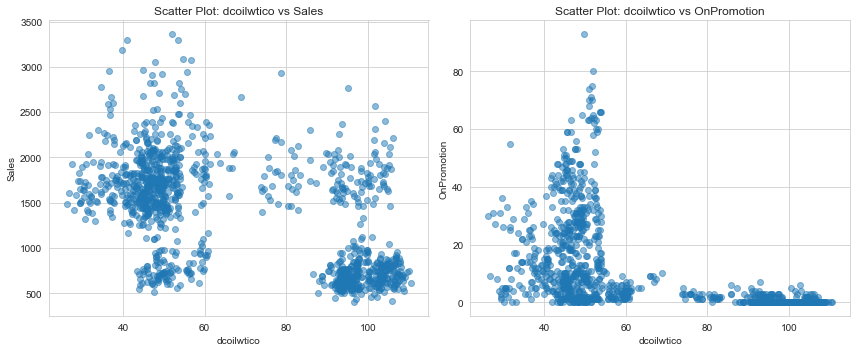

In [9]:
# Scatter plot dcoilwtico vs sales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_beverages["dcoilwtico"], df_beverages["sales"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("Sales")
plt.title("Scatter Plot: dcoilwtico vs Sales")

# Scatter plot dcoilwtico vs onpromotion
plt.subplot(1, 2, 2)
plt.scatter(df_beverages["dcoilwtico"], df_beverages["onpromotion"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("OnPromotion")
plt.title("Scatter Plot: dcoilwtico vs OnPromotion")

plt.tight_layout()
plt.show()

non-linear distribution of oil price comparison with sales and promotion, then using polymonial interpolation to fill Missing Value

In [30]:
#Polymonial Interpolation
df_beverages['dcoilwtico_interpolate'] = df_beverages['dcoilwtico'].interpolate(method='polynomial', order=2)

# Fill missing values using backward fill
df_beverages['dcoilwtico_interpolate'] = df_beverages['dcoilwtico_interpolate'].fillna(method='bfill')

In [31]:
df_beverages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    1688 non-null   datetime64[ns]
 1   id                      1684 non-null   float64       
 2   store_nbr               1688 non-null   int32         
 3   family                  1688 non-null   object        
 4   sales                   1688 non-null   float64       
 5   onpromotion             1688 non-null   float64       
 6   dcoilwtico              1163 non-null   float64       
 7   dcoilwtico_interpolate  1688 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int32(1), object(1)
memory usage: 99.0+ KB


Comparing data after Interpolate and Backward Fill

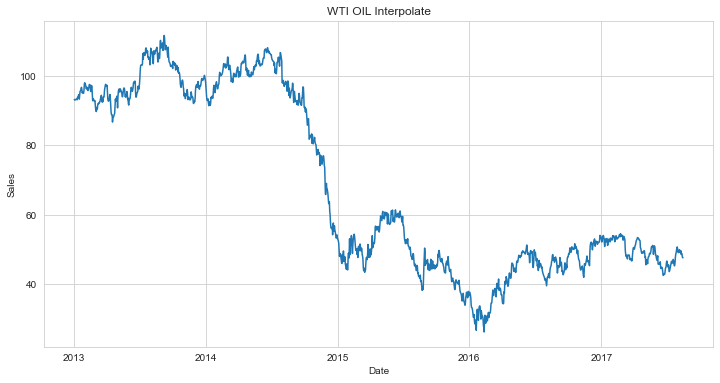

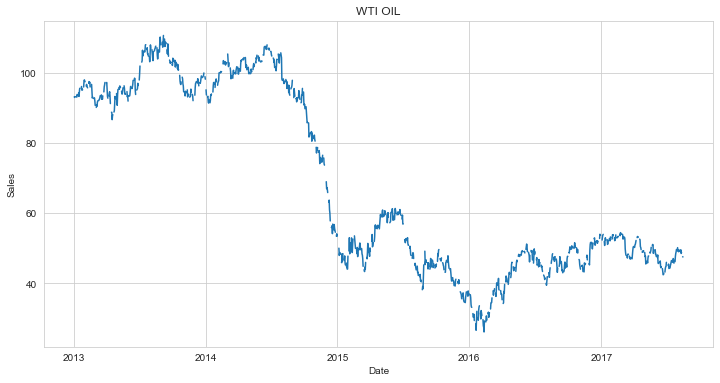

In [13]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(df_beverages['date'], df_beverages['dcoilwtico_interpolate'])
plt.title('WTI OIL Interpolate')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)

plt.figure(figsize=(12, 6))
plt.plot(df_beverages['date'], df_beverages['dcoilwtico'])
plt.title('WTI OIL')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

# Modeling

In [14]:
df_beverages

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN,93.140000
36,3237,2013-01-02,5,BEVERAGES,947.0,0,93.14,93.140000
69,5019,2013-01-03,5,BEVERAGES,847.0,0,92.97,92.970000
102,6801,2013-01-04,5,BEVERAGES,859.0,0,93.12,93.120000
135,8583,2013-01-05,5,BEVERAGES,912.0,0,NaN,93.205338
...,...,...,...,...,...,...,...,...
55410,2993433,2017-08-11,5,BEVERAGES,1717.0,11,48.81,48.810000
55443,2995215,2017-08-12,5,BEVERAGES,1353.0,6,NaN,48.717426
55476,2996997,2017-08-13,5,BEVERAGES,1838.0,9,NaN,48.020802
55509,2998779,2017-08-14,5,BEVERAGES,1771.0,10,47.59,47.590000


LSTM for Beverages

In [32]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

In [33]:
df_beverages = df_beverages.drop(['store_nbr', 'family', 'dcoilwtico', 'id'], axis=1)

In [34]:
df_beverages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    1688 non-null   datetime64[ns]
 1   sales                   1688 non-null   float64       
 2   onpromotion             1688 non-null   float64       
 3   dcoilwtico_interpolate  1688 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 52.9 KB


In [35]:
# Preprocessing
scaler_endog = MinMaxScaler()
scaler_exog = MinMaxScaler()

endog = df_beverages[['sales', 'onpromotion']]
exog =  df_beverages[['dcoilwtico_interpolate']]

# Scaling the data (already done earlier)
endog_scaled = scaler_endog.fit_transform(endog)
exog_scaled = scaler_exog.fit_transform(exog)

In [36]:
# Combine exogenous (exog) and endogenous (endog) features into x
x = np.concatenate([exog_scaled, endog_scaled], axis=1)

# The target variable 'y' is the endog_scaled
y = endog_scaled  # 'sales' and 'onpromotion' as the target (2 columns)

In [37]:
def load_data(X, seq_len, train_size=0.9):
    amount_of_features = X.shape[1]
    X_mat = X
    sequence_length = seq_len + 1
    data = []

    for index in range(len(X_mat) - sequence_length):
        data.append(X_mat[index: index + sequence_length])

    data = np.array(data)
    train_split = int(round(train_size * data.shape[0]))
    train_data = data[:train_split, :]

    x_train = train_data[:, :-1]
    y_train = train_data[:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    x_test = data[train_split:, :-1]
    y_test = data[train_split:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    # Check shapes before reshaping
    print(f"x_train shape (before reshape): {x_train.shape}")
    print(f"y_train shape (before reshape): {y_train.shape}")

    # Reshape x_train and x_test to 3D arrays for LSTM input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], amount_of_features))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], amount_of_features))

    return x_train, y_train, x_test, y_test

# Setting window size
window = 22
X_train, y_train, X_test, y_test = load_data(x, window)

# Print the shapes of data after loading and reshaping
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

x_train shape (before reshape): (1498, 22, 3)
y_train shape (before reshape): (1498, 2)
X_train shape: (1498, 22, 3), y_train shape: (1498, 2)
X_test shape: (167, 22, 3), y_test shape: (167, 2)


In [38]:
# Define hyperparameter search space
search_space = {
    "units": (50, 200),          # LSTM units (int will be cast later)
    "dropout_rate": (0.1, 0.5),  # Dropout rate (between 10% and 50%)
    "learning_rate": (1e-5, 1e-2) # Learning rate (log scale search)
}

def build_and_train_model(units, dropout_rate, learning_rate):
    """
    Builds and trains an LSTM model with given hyperparameters.

    Parameters:
        units (float): Number of LSTM units (cast to int).
        dropout_rate (float): Dropout rate for regularization.
        learning_rate (float): Learning rate for optimizer.

    Returns:
        float: Negative validation loss (for Bayesian Optimization).
    """
    # Ensure units is an integer
    units = int(units)

    # Initialize the model
    model = Sequential([
        LSTM(units=units, input_shape=(window, X_train.shape[2]), return_sequences=False),
        Dropout(rate=dropout_rate),
        Dense(units=50, activation="tanh"),
        Dense(units=2, activation="linear")])

    # Compile the model with Adam optimizer
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mean_squared_error")

    # Train the model with validation split
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

    # Return negative validation loss since Bayesian Optimization minimizes
    return -history.history["val_loss"][-1]

In [39]:
# Perform Bayesian Optimization
optimizer = BayesianOptimization(
    f=build_and_train_model,
    pbounds=search_space,
    random_state=42,
    verbose=2)

# Run optimization process
optimizer.maximize(init_points=5, n_iter=20)

# Extract best hyperparameters
best_hyperparams = optimizer.max["params"]
best_units = int(best_hyperparams["units"])
best_dropout_rate = best_hyperparams["dropout_rate"]
best_learning_rate = best_hyperparams["learning_rate"]

print(f"Optimal Hyperparameters: {best_hyperparams}")

|   iter    |  target   | dropou... | learni... |   units   |
-------------------------------------------------------------


C:\Users\ASUS\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| 1         | -0.01906  | 0.2498    | 0.009508  | 159.8     |
| 2         | -0.01941  | 0.3395    | 0.001569  | 73.4      |
| 3         | -0.01839  | 0.1232    | 0.008663  | 140.2     |
| 4         | -0.01982  | 0.3832    | 0.0002156 | 195.5     |
| 5         | -0.01818  | 0.433     | 0.002131  | 77.27     |


C:\Users\ASUS\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| 6         | -0.01879  | 0.4071    | 0.004103  | 77.22     |


...

| 23        | -0.01803  | 0.2345    | 0.0005907 | 181.8     |


C:\Users\ASUS\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| 24        | -0.01763  | 0.4521    | 0.008379  | 98.12     |


C:\Users\ASUS\anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| 25        | -0.01944  | 0.4352    | 0.008227  | 98.08     |
Optimal Hyperparameters: {'dropout_rate': 0.45211115556910897, 'learning_rate': 0.008378662200367116, 'units': 98.11643570854483}


In [40]:
# Train final model with best hyperparameters
final_model = Sequential([
    LSTM(units=best_units, input_shape=(window, X_train.shape[2])),
    Dropout(rate=best_dropout_rate),
    Dense(units=50, activation="tanh"),
    Dense(units=2, activation="linear")
])

# Compile final model
final_model.compile(optimizer=Adam(learning_rate=best_learning_rate), loss="mean_squared_error")

# Train final model with verbose logging
start_time = time.time()
history = final_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds.")

# Evaluate the model on the test set
test_loss = final_model.evaluate(X_test, y_test, verbose=1)
print(f"Final Test Loss: {test_loss:.6f}")

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0316 - val_loss: 0.0246
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0080 - val_loss: 0.0220
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0078 - val_loss: 0.0244
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0082 - val_loss: 0.0200
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0081 - val_loss: 0.0186
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0069 - val_loss: 0.0224
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0071 - val_loss: 0.0244
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0057 - val_loss: 0.0237
Epoch 9/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0068 - val_loss: 0.0280
Epoch 10/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0068 - val_loss: 0.0168
Epoch 11/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0069 - val_loss: 0.0186
Epoch 12/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0061 - val_loss: 0.0170
Epoch 69/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0045 - val_loss: 0.0256
Epoch 70/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0046 - val_loss: 0.0210
Epoch 71/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0046 - val_loss: 0.0179
Epoch 72/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0051 - val_loss: 0.0174
Epoch 73/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0040 - val_loss: 0.0167
Epoch 74/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0043 - val_loss: 0.0230
Epoch 75/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0043 - val_loss: 0.0220
Epoch 76/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0054 - val_loss: 0.0189
Epoch 77/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0051 - val_loss: 0.0159
Epoch 78/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0051 - val_loss: 0.0187
Epoch 79/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - l

In [41]:
# Predictions
trainPredict = final_model.predict(X_train)
testPredict = final_model.predict(X_test)

# Inverse transform to get the actual values
trainPredict = scaler_endog.inverse_transform(trainPredict)
trainY = scaler_endog.inverse_transform(y_train)
testPredict = scaler_endog.inverse_transform(testPredict)
testY = scaler_endog.inverse_transform(y_test)

# Plotting
plot_predicted_sales = testPredict[:, 0].reshape(-1, 1)
plot_predicted_onpromotion = testPredict[:, 1].reshape(-1, 1)

plot_actual_sales = testY[:, 0].reshape(-1, 1)
plot_actual_onpromotion = testY[:, 1].reshape(-1, 1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [24]:
print(final_model.summary())

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                  │ (None, 140)            │        80,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 140)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 50)             │         7,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,378 (1.00 MB)

 Trainable params: 87,792 (342.94 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 175,586 (685.89 KB)

None


In [42]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales = mean_squared_error(trainY[:, 0], trainPredict[:, 0]) ** 0.5
testScore_sales = mean_squared_error(testY[:, 0], plot_predicted_sales[:, 0]) ** 0.5

trainScore_onpromotion = mean_squared_error(trainY[:, 1], trainPredict[:, 1]) ** 0.5
testScore_onpromotion = mean_squared_error(testY[:, 1], plot_predicted_onpromotion[:, 0]) ** 0.5

In [43]:
print(f'Train Score for sales: {trainScore_sales:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion:.2f} RMSE')

Train Score for sales: 294.98 RMSE
Test Score for sales: 348.64 RMSE
Train Score for onpromotion: 5.36 RMSE
Test Score for onpromotion: 5.88 RMSE


In [44]:
# Sales
trainMAE_sales = mean_absolute_error(trainY[:, 0], trainPredict[:, 0])
testMAE_sales = mean_absolute_error(testY[:, 0], plot_predicted_sales[:, 0])

# On Promotion
trainMAE_onpromotion = mean_absolute_error(trainY[:, 1], trainPredict[:, 1])
testMAE_onpromotion = mean_absolute_error(testY[:, 1], plot_predicted_onpromotion[:, 0])

print('Train MAE for Sales:', trainMAE_sales)
print('Test MAE for Sales:', testMAE_sales)
print('Train MAE for On Promotion:', trainMAE_onpromotion)
print('Test MAE for On Promotion:', testMAE_onpromotion)

Train MAE for Sales: 209.88851150492323
Test MAE for Sales: 254.5120623011789
Train MAE for On Promotion: 2.5259431180990584
Test MAE for On Promotion: 4.156945716835068


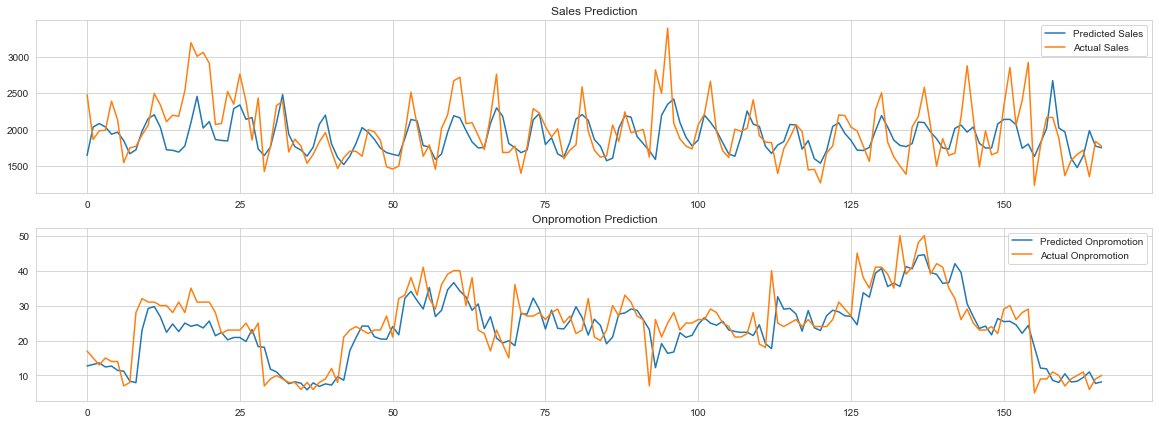

In [45]:
# Plot the results for both targets
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(plot_predicted_sales), label='Predicted Sales')
plt.plot(pd.DataFrame(plot_actual_sales), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(plot_predicted_onpromotion), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(plot_actual_onpromotion), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction')

plt.show()